In [110]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.kernel_ridge import KernelRidge
import warnings
warnings.filterwarnings('ignore')


In [91]:
# Charger le dataset
Dataset = pd.read_csv("vinted_data.csv", sep=',', decimal=',')

Dataset.head()
Dataset.info()
Dataset.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   url         384 non-null    str    
 1   etat        384 non-null    str    
 2   matiere     316 non-null    str    
 3   couleur     384 non-null    str    
 4   categorie   384 non-null    str    
 5   likes       382 non-null    float64
 6   prix        384 non-null    str    
 7   prix_total  384 non-null    str    
 8   collection  384 non-null    str    
dtypes: float64(1), str(8)
memory usage: 27.1 KB


url            0
etat           0
matiere       68
couleur        0
categorie      0
likes          2
prix           0
prix_total     0
collection     0
dtype: int64

In [92]:
print(Dataset.shape)

(384, 9)


In [93]:
Dataset.duplicated().sum()

np.int64(0)

In [94]:
# Remplacer les valeurs manquantes de la colonne "matiere" par "Non précisée"
Dataset["matiere"] = Dataset["matiere"].fillna("Non précisée")

In [95]:
# Créer une nouvelle colonne "matiere_principal" en extrayant la première matière de la colonne "matiere"
mapping = {
    "Coton": "fibre naturelle végétale",
    "Lin": "fibre naturelle végétale",
    "Jute": "fibre naturelle végétale",
    "Denim": "fibre naturelle végétale",

    "Laine": "fibre naturelle animale",
    "Soie": "fibre naturelle animale",

    "Viscose": "fibre artificielle",

    "Polyester": "fibre synthétique",
    "Nylon": "fibre synthétique",
    "Élasthanne": "fibre synthétique",
    "Acrylique": "fibre synthétique",

    "Cuir": "cuir",
    "Daim": "cuir",
    "Cuir verni": "cuir",

    "Cuir synthétique": "autres",
    "Dentelle": "autres",
    "Carton": "autres"
}

Dataset["matiere_principal"] = (
    Dataset["matiere"]
    .str.split(",")
    .str[0]
    .str.strip()
    .map(mapping)
    .fillna("autres")
)

In [ ]:

# Fonction pour nettoyer et normaliser les textes
def nettoyer_texte(x):
    if pd.isna(x):
        return ""
    x = str(x).lower().strip()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    return x
# Appliquer la fonction de nettoyage à la colonne "couleur"
def categoriser_couleur(couleur):
    couleur = nettoyer_texte(couleur)

    if couleur == "":
        return "autres"

    # si plusieurs couleurs : on prend la première
    couleur = couleur.split(",")[0].strip()

    if any(mot in couleur for mot in ["noir", "gris", "anthracite", "argente", "argent"]):
        return "noir/gris"

    elif any(mot in couleur for mot in ["blanc", "beige", "ecru", "ivoire", "creme"]):
        return "blanc/beige"

    elif any(mot in couleur for mot in ["marron", "camel", "taupe", "chocolat"]):
        return "marron"

    elif any(mot in couleur for mot in ["bleu", "marine", "turquoise", "denim", "jean"]):
        return "bleu"

    elif any(mot in couleur for mot in ["vert", "kaki", "olive"]):
        return "vert"

    elif any(mot in couleur for mot in ["rouge", "bordeaux", "corail"]):
        return "rouge"

    elif any(mot in couleur for mot in ["rose", "violet", "lilas", "fuchsia", "mauve"]):
        return "rose/violet"

    elif any(mot in couleur for mot in ["jaune", "orange", "ocre", "moutarde", "dore"]):
        return "jaune/orange"

    elif any(mot in couleur for mot in ["multicolore", "imprime", "fleuri", "raye", "leopard", "zebre", "python"]):
        return "motif/multicolore"

    else:
        return "autres"

Dataset["couleur_generique"] = Dataset["couleur"].apply(categoriser_couleur)

In [97]:
# Remplacer les valeurs manquantes de la colonne "likes" par 0
Dataset["likes"] = Dataset["likes"].fillna(0)


In [98]:
# Supprimer les lignes où la conversion a échoué (valeurs NaN)
Dataset.drop(columns=["url"], inplace=True)

In [99]:
print(Dataset.isnull().sum())

etat                 0
matiere              0
couleur              0
categorie            0
likes                0
prix                 0
prix_total           0
collection           0
matiere_principal    0
couleur_generique    0
dtype: int64


In [100]:
# Convertir les colonnes "likes", "prix" et "prix_total" en numérique, en remplaçant les valeurs non convertibles par NaN
Dataset["prix"] = (
    Dataset["prix"]
    .astype(str)
    .str.replace("\u202f", "", regex=False)
    .str.replace("\xa0", "", regex=False)
    .str.replace("€", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

Dataset["prix"] = pd.to_numeric(Dataset["prix"], errors="coerce")
Dataset["prix_total"] = (
    Dataset["prix_total"]
    .astype(str)
    .str.replace("\u202f", "", regex=False)
    .str.replace("\xa0", "", regex=False)
    .str.replace("€", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

Dataset["prix_total"] = pd.to_numeric(Dataset["prix_total"], errors="coerce")

In [101]:
Dataset.to_csv("vinted_data_clean.csv", index=False)
dataset_clean = pd.read_csv("vinted_data_clean.csv", sep=',')

In [102]:
Dataset.head()

,etat,matiere,couleur,categorie,likes,prix,prix_total,collection,matiere_principal,couleur_generique
0,Neuf sans étiquette,Coton,Blanc,Hauts et t-shirts,41.0,3.0,3.85,femme,fibre naturelle végétale,blanc/beige
1,Très bon état,Coton,Blanc,Hauts et t-shirts,49.0,4.0,4.63,femme,fibre naturelle végétale,blanc/beige
2,Neuf sans étiquette,"Coton, Polyester",Beige,Pantalons et leggings,24.0,10.0,10.95,femme,fibre naturelle végétale,blanc/beige
3,Neuf sans étiquette,"Polyester, Élasthanne",Noir,Pantalons et leggings,11.0,15.0,16.38,femme,fibre synthétique,noir/gris
4,Très bon état,Coton,Blanc,Hauts et t-shirts,18.0,6.0,6.61,femme,fibre naturelle végétale,blanc/beige


In [109]:
# Afficher les statistiques descriptives, la forme du dataset et le nombre de valeurs manquantes
print(dataset_clean.shape)
print(dataset_clean.isnull().sum())

(384, 10)
etat                 0
matiere              0
couleur              0
categorie            0
likes                0
prix                 0
prix_total           0
collection           0
matiere_principal    0
couleur_generique    0
dtype: int64


In [104]:
dataset_clean.describe()

,likes,prix,prix_total
count,384.000000,384.000000,384.000000
mean,29.268229,13.994453,15.353698
std,32.476035,16.269817,17.232584
min,0.000000,2.000000,2.800000
25%,9.750000,5.000000,5.950000
50%,19.000000,9.100000,10.170000
75%,37.000000,15.000000,16.450000
max,222.000000,175.000000,184.450000


In [105]:
dataset_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   etat               384 non-null    str    
 1   matiere            384 non-null    str    
 2   couleur            384 non-null    str    
 3   categorie          384 non-null    str    
 4   likes              384 non-null    float64
 5   prix               384 non-null    float64
 6   prix_total         384 non-null    float64
 7   collection         384 non-null    str    
 8   matiere_principal  384 non-null    str    
 9   couleur_generique  384 non-null    str    
dtypes: float64(3), str(7)
memory usage: 30.1 KB


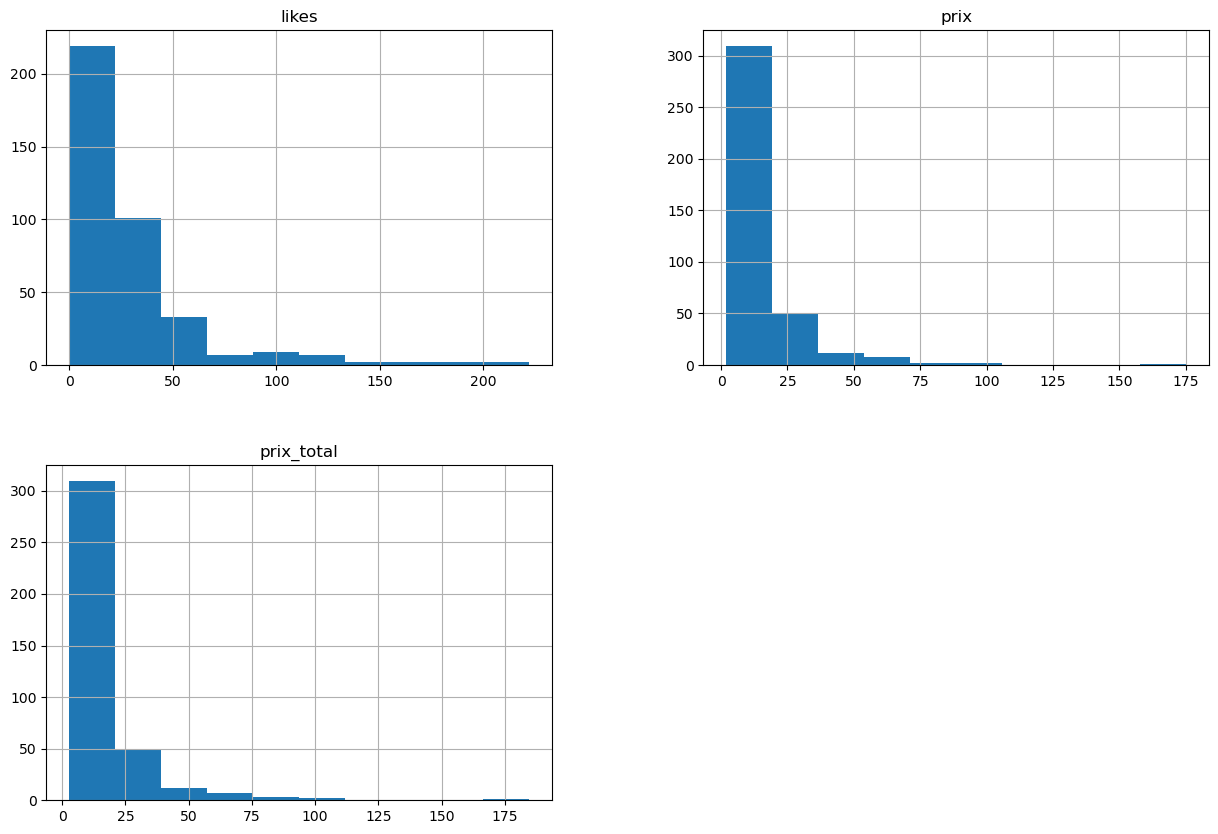

In [106]:
dataset_clean.hist(figsize=(15,10))
plt.show()

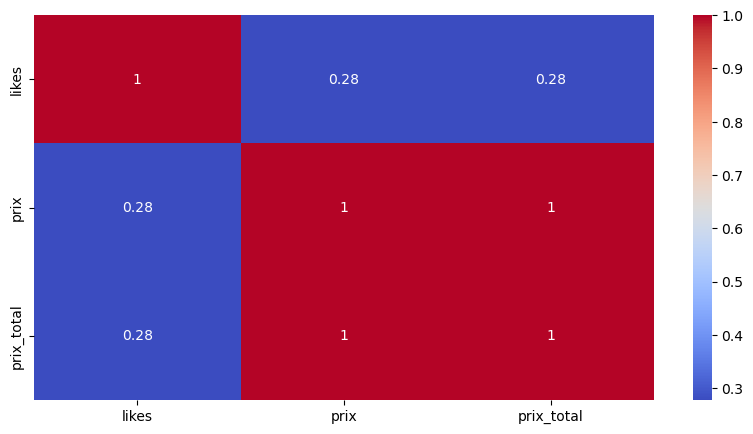

In [107]:
Dataset_numeric = dataset_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(10,5))
sns.heatmap(Dataset_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

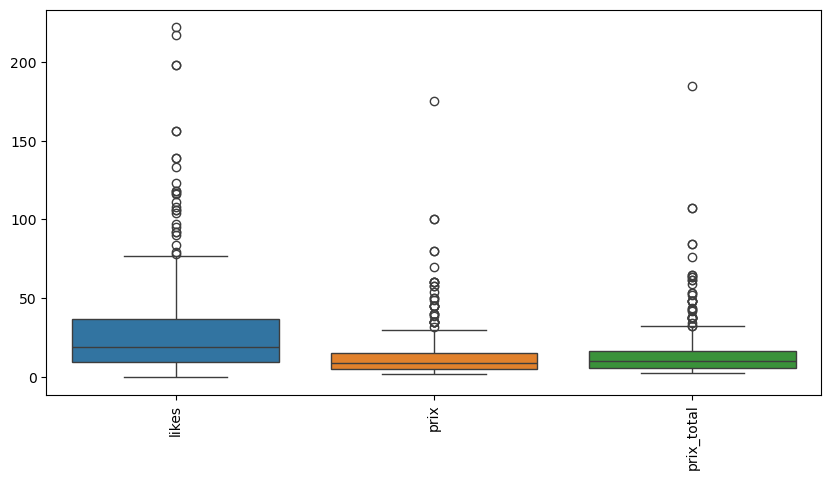

In [108]:
plt.figure(figsize=(10,5))
sns.boxplot(data=dataset_clean.select_dtypes(include=[np.number]))
plt.xticks(rotation=90)
plt.show()